# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.
Note that throughout we use the numerator (Jacobian) layout, in which the derivative of a
*scalar* with respect to a vector is a **row** vector — consistent with the example
$\partial(\boldsymbol{A}\boldsymbol{x})/\partial\boldsymbol{x}=\boldsymbol{A}$ in the hint below and with Faisal et al.; if you prefer the
column-gradient convention you will obtain the equivalent transposed results, e.g.
$(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{a}$ instead of $\boldsymbol{a}^T(\boldsymbol{A}+\boldsymbol{A}^T)$.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

Part 1)

Assuming that a and x are vectors of length n, the scalar can be written as 
\begin{equation*}
    a^{T} x = [a_1 x_1 + a_2 x_2 + ... + a_n x_n] = \sum^{n-1}_{i = 0} a_i x_i
\end{equation*}

The partial derivative can be written as 
\begin{equation*}
    \frac{\partial (a^T x)}{\partial x} = \left[ \frac{\partial (a^T x)}{\partial x_1} \, \frac{\partial (a^T x)}{\partial x_2} ... \frac{\partial (a^T x)}{\partial x_n}\right]
\end{equation*}

Since the sum of $a^T x$ only contains one term per component in x, we get the following
\begin{equation*}
    \frac{\partial (a^T x)}{\partial x} = [a_1 \, a_2 ... a_3] = a^T
\end{equation*}


Part 2)

Using that a is a vector of length n and A is an nxn matrix, the scalar can be written as
\begin{equation*}
    a^T Aa = \sum^{n-1}_{i=0} \sum^{n-1}_{j=0} a_i A_{ij} a_j
\end{equation*}

Now, we differentiate the whole term with respect to all k elements in a. Since $a_k$ can appear as either $a_k = a_i$ or $a_k = a_j$, we get two contributions
\begin{equation*}
    \frac{\partial (a^T Aa)}{\partial a_k} = \sum^{n-1}_{i=0} a_i A_{ik} + \sum^{n-1}_{j=0} a_j A_{kj}
\end{equation*}

By looking at each sum separately, we see that:

Each term in $\sum^{n-1}_{i=0} a_i A_{ik}$ is just the k-th component of $a^T A$.

Each term in $\sum^{n-1}_{j=0} a_j A_{kj}$ is the k-th component of $a^T A^T$.

Substituting the terms gives
\begin{equation*}
    \frac{\partial (a^T Aa)}{\partial a_k} = (a^T A)_k + (a^T A^T)_k = (a^T (A + A^T))_k
\end{equation*}

The result from all $a_k$ gives a row vector $a^T (A + A^T)$.

Part 3)

We begin by defining a function $f(s)$ and a vector $v$ as such
\begin{align*}
    & f(s) = (x-As)^T (x-As) = \sum^{n-1}_{i=0} (x-As)^2 \\
    & v = x-As
\end{align*}

We can now write that $f(s) = v^2 v$
\begin{equation*}
    \frac{\partial f(s)}{\partial s} = 2 v^T \cdot \frac{\partial v}{\partial t} = 2v^T \cdot (-A) = -2(x-As)^T A
\end{equation*}

We can derive the 2nd derivative by writing the term with respect to $s^T$
\begin{align*}
    \frac{\partial f(s)}{\partial s^T} = &-2A^T (x-As) \\
    & \downarrow \\
    \frac{\partial}{\partial s} \, \frac{\partial f(s)}{\partial s^T} &= 2A^T A
\end{align*}
... where $2A^T A$ is the same as $2H$ (the Hessian matrix).

## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [453]:
import numpy as np

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

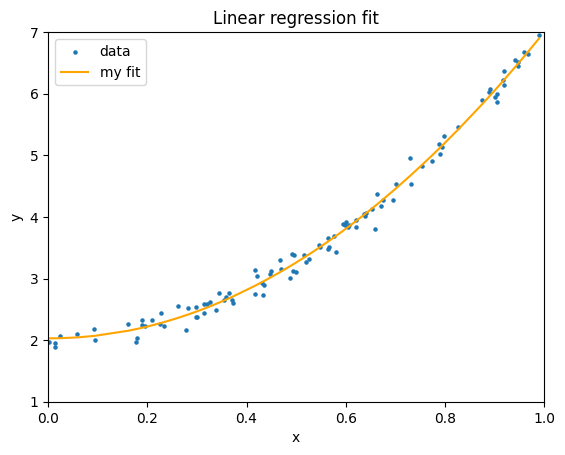

In [454]:
import matplotlib.pyplot as plt

X = np.zeros((100,3))
for i in range(3):
    X[:,i] = x.flatten()**i

theta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_thilde = X @ theta

sort_idx = np.argsort(x.flatten())
x_sorted = x.flatten()[sort_idx]
y_thilde_sorted = y_thilde.flatten()[sort_idx]

plt.scatter(x,y, s=5, label = 'data')
plt.plot(x_sorted, y_thilde_sorted, color = 'orange',label = 'my fit')
plt.axis([0.0,1.0,1.0,7.0])
plt.title('Linear regression fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

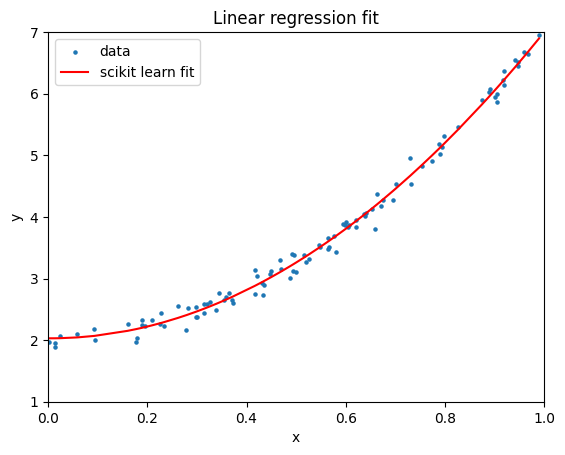

In [455]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression(fit_intercept=False).fit(X,y)
y_thilde_learn = linreg.predict(X)
y_learn_sorted = y_thilde_learn.flatten()[sort_idx]

plt.scatter(x,y, s=5, label = 'data')
plt.plot(x_sorted, y_learn_sorted, color = 'red', label = 'scikit learn fit')
plt.axis([0.0,1.0,1.0,7.0])
plt.title('Linear regression fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

In [456]:
from sklearn.metrics import mean_squared_error, r2_score

MSE = mean_squared_error(y, y_thilde)
MSE_learn = mean_squared_error(y, y_thilde_learn)

r2 = r2_score(y, y_thilde)
r2_learn = r2_score(y, y_thilde_learn)

print(f'The mean square error using our own function is: {MSE}')
print(f'The mean square error using the scikit-learn is: {MSE_learn}')

print(f'The R^2 score i using our own function is {r2}')
print(f'The R^2 score i using the scikit-learn is {r2_learn}')


The mean square error using our own function is: 0.013728156746263005
The mean square error using the scikit-learn is: 0.013728156746263005
The R^2 score i using our own function is 0.9928732429893427
The R^2 score i using the scikit-learn is 0.9928732429893427


Comment:

The written- and the sklean-model gives the same values of MSE and $R^2$-score. The MSE-value indicates the precision of the fit, where low values means that the fit is good. The $R^2$-score indicates how well the model predicts the data and a score of 1 means there are no errors. 

When we increase the coefficient before the stocastic noise term, the MSE inreases while the $R^2$-score decreases. This means that the model is less precise and the prediction has more errors. This highlights the importance of reducing noise in order to get a better fit and prediction.



## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [462]:
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

In [458]:
# Your code for exercise 3 here
from sklearn.model_selection import train_test_split

def create_matrix(x, degree):
    X = np.zeros((len(x), degree + 1))
    for i in range (degree + 1):
        X[:,i] = x.flatten()**i
    return X

degree = 5
X = create_matrix(x, degree)
X_train, X_test, y_train, y_test, x_train, x_test = train_test_split(X, y, x, test_size=0.2, random_state = 42)


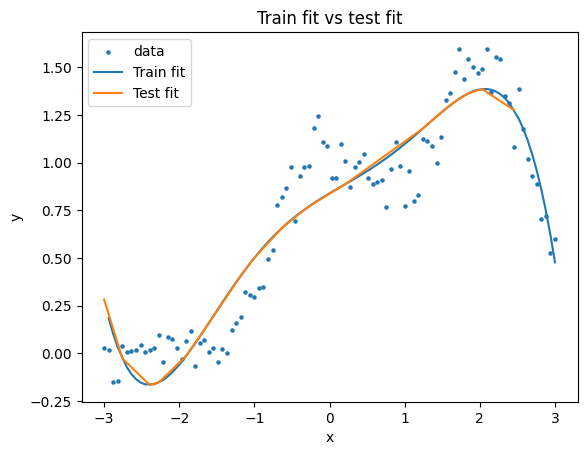

The mean squared error for the training data: 0.03059875491669036
The mean squared error for the testing data: 0.029313425085392142


In [459]:
OLS = LinearRegression(fit_intercept=False).fit(X_train, y_train)
y_thilde_train = OLS.predict(X_train)
y_thilde_test = OLS.predict(X_test)

train_index = np.argsort(x_train.flatten())
test_index = np.argsort(x_test.flatten())

x_train_sorted = x_train.flatten()[train_index]
x_test_sorted = x_test.flatten()[test_index]
y_train_sorted = y_thilde_train.flatten()[train_index]
y_test_sorted = y_thilde_test.flatten()[test_index]

plt.scatter(x, y, s=5, label = 'data')
plt.plot(x_train_sorted, y_train_sorted, label = 'Train fit')
plt.plot(x_test_sorted, y_test_sorted, label = 'Test fit')
plt.title('Train fit vs test fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

MSE_training = mean_squared_error(y_train, y_thilde_train)
MSE_test = mean_squared_error(y_test, y_thilde_test)

print(f'The mean squared error for the training data: {MSE_training}')
print(f'The mean squared error for the testing data: {MSE_test}')


Comment:

I am expecting that the testing MSE is bigger than the training MSE in the end, but the [-3,3] boundary along the x-axis is too short. In this case, the two MSE values of the training and the testing are 0.031 and 0.029 respectively. When I widen the boundary to [-4,4], the MSE values of the training and the testing are 0.030 and 0.037 respectively. Meaning that the training data will be more accurate if only we provide enough data. 

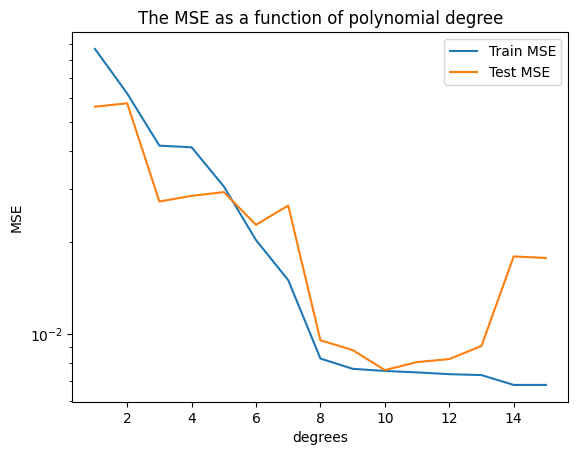

Best polynomial degree (lowest test MSE): 10


In [460]:
max_degree = 15
train_errors = np.zeros(max_degree)
test_errors = np.zeros(max_degree)

for d in range(1, max_degree + 1):
    X_poly_d = create_matrix(x, d)
    X_train, X_test, y_train, y_test = train_test_split(X_poly_d, y, test_size=0.2, random_state = 42)

    theta_d, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
    y_train_thilde = X_train @ theta_d
    y_test_thilde = X_test @ theta_d

    train_errors[d-1] = mean_squared_error(y_train, y_train_thilde)
    test_errors[d-1] = mean_squared_error(y_test, y_test_thilde)

degrees = np.arange(1, max_degree +1)
best_degree = degrees[np.argmin(test_errors)]


plt.plot(degrees, train_errors, label = 'Train MSE')
plt.plot(degrees, test_errors, label = 'Test MSE')
plt.yscale('log')
plt.title(f'The MSE as a function of polynomial degree')
plt.xlabel('degrees')
plt.ylabel('MSE')
plt.legend()
plt.show()


print(f'Best polynomial degree (lowest test MSE): {best_degree}')

## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

In [461]:
# Your code for exercise 4 here
